<a href="https://colab.research.google.com/github/Primo-J/Jose_INFO4670_Spring2026/blob/main/INFO_CSCE4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> False Positives are more costly. A False Positive means a legitimate message is silently blocked. For example, a user misses a doctos's appointment reminder or a one time bank verification code, causing real harm. A False Negative simply means a spam message get through, which is annoying but recoverable as the user can simply delete it. In a general purpose carrier level spam filter, blocking real messages destroys user trust far more severely than letting occasional spam slip through.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Precision should be the primary metric. Precision measures what fraction of messages flagged as spam are actually spam. In other words, it directly penalizes False Positives. Since we established that blocking legitimate messages is the costlier error, we want to be very confident before labeling something as spam. A high precision model will only block messages it is nearly certain are spam, minimizing the chance of a real message being lost.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts "ham" would achieve approximately 86.6% accuracy (since 86.6% of messages are ham). That number is deeply misleading because the model catches zero spam messages. It's Recall and F1-Score are both 0%. This is the Accuracy Trap, which is when classes are imbalanced, a classifier can score high accuracy by simply ignoring the minority class entirely. Accuacy alone cannot reveal this failure, which is why Precision, Recall, and F1 are more informative for imbalanced problems like spam detection.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


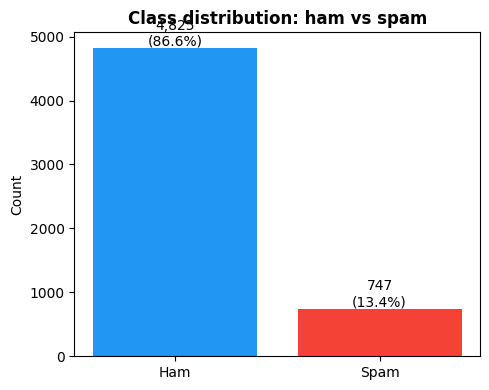

In [3]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


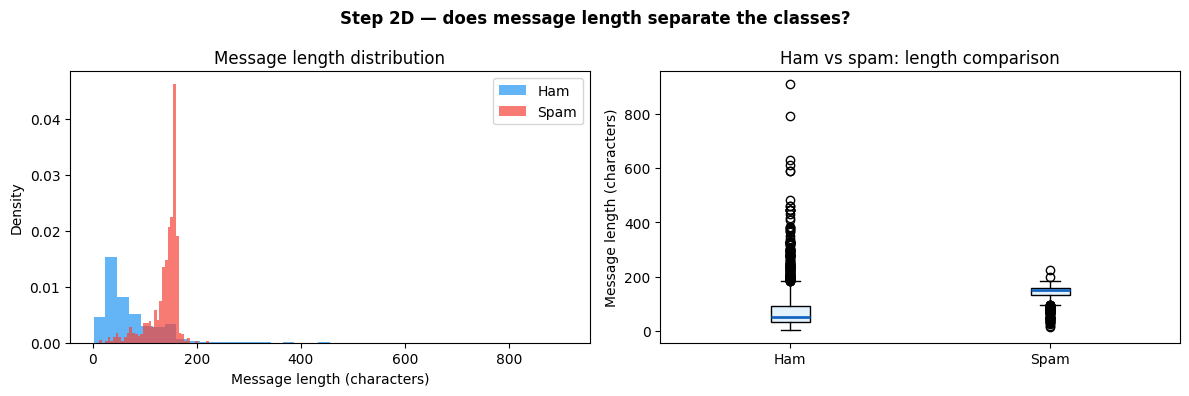

In [5]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [9]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    d['has_url'] = msg.str.contains(r'http|www|\.com|\.uk|\.net', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    d['has_cta'] = msg.str.contains(r'btxt\b|\breply\b|\bstop\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_url                18.6%    0.4%  +18.2%
has_cta                22.0%    1.6%  +20.3%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


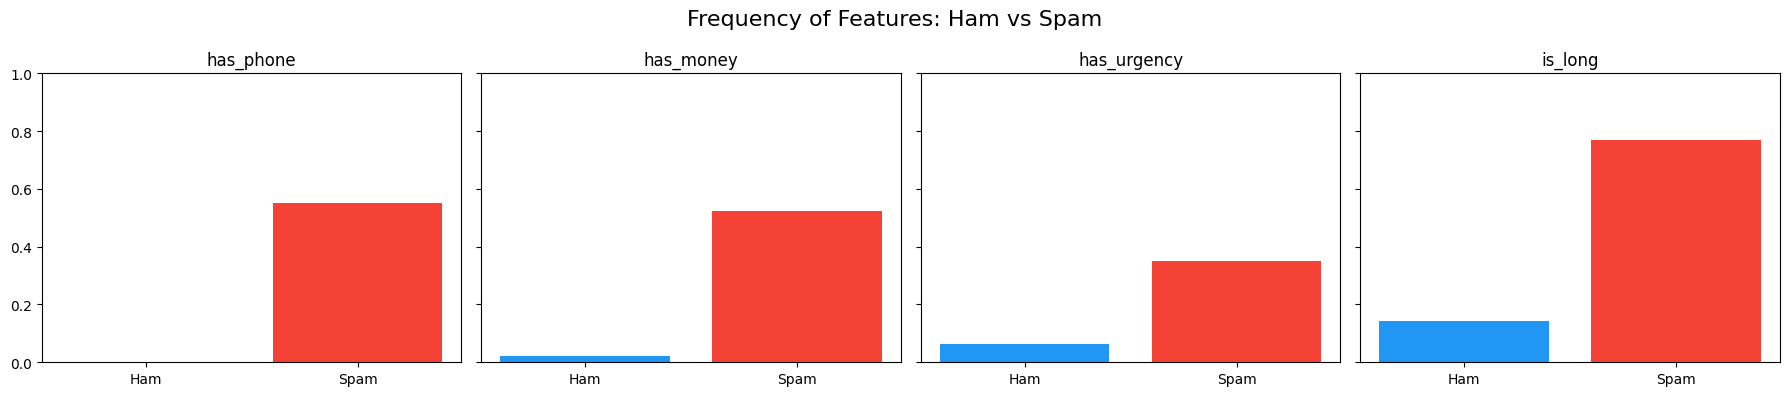

In [8]:
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(18, 4), sharey=True)

for i, feat in enumerate(feature_cols):
  spam_rate = df[df['spam'] == 1][feat].mean()
  ham_rate = df[df['spam'] == 0][feat].mean()

  axes[i].bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['#2196F3', '#F44336'])
  axes[i].set_title(feat)
  axes[i].set_ylim(0, 1)

plt.suptitle('Frequency of Features: Ham vs Spam', fontsize=16)
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> has_url: Legitimate SMS messages between individuals rarely contain full web addresses, whereas spam is almost always designed to redirect you to a phishing or marketing site.

*Feature 2 — name and explanation:*
> has_cta: Words like "txt" (instead of "text") and instructions like "reply STOP" are hallmark patterns of automated bulk SMS services used by spammers.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The feature with the largest gap between spam and ham is "is_long". A large gap indicates that a feature is a strong "discriminator". In terms of Information Gain, a feature like is_long significantly reduces entropy because it separates the two classes much more cleanly than a feature with a small gap. A large gap matters because the Decision Tree algorithm aims to split the data as effectively as possible at each step, it will prioritize the feature with the highest information Gain to serve as the root node (the very first split in the tree).

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> The spam example "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s"

is_long fails here as this message is approximately 115 characters long and because it falls under the 130 character threshold used for the is_long feature, this strong spam indicator will return a 0.

has_money fails here as the message uses "social" or "dating" lures rathern than financial ones. It does not contain any of the trigger words like "win", "cash", or "prize", so this feature will return a 0.

has_phone / has_url fails here as the message does not provide a direct phone number or a website link to click. Instead it relies on the user replying to the shortcode. If the regex for has_phone does not specifically catch the sender's shortcode, these features will return a zero.

has_urgency fails as the tone is informal and conversational ("up for it still?") rather than using high pressure urgency keywords like "urgent" or "expires". This feature will also return a 0.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [10]:
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Spam rate in Training set: {y_train.mean():.1%}")
print(f"Spam rate in Test set: {y_test.mean():.1%}")

Training set size: 4179 samples
Test set size: 1393 samples
Spam rate in Training set: 13.4%
Spam rate in Test set: 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> Passing stratify=y ensures that the train/test split maintains the same proportion of class labels (spam vs ham) as the original data set.

If stratification is skipped on an imbalanced dataset, a random split might result in a training set with very few spam examples or a test set that does not accurately reflect the real world distribution. This leads to a model that is poorly trained to recognize the minority class (spam) and evaluation metrics that are unreliable or biased.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross validation would be prefered in small datasets. In a single 75/25 split of a small sample, the specific data points chosen for the test set can significantly swing the performance metrics by chance.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves in the tree: 14
------------------------------


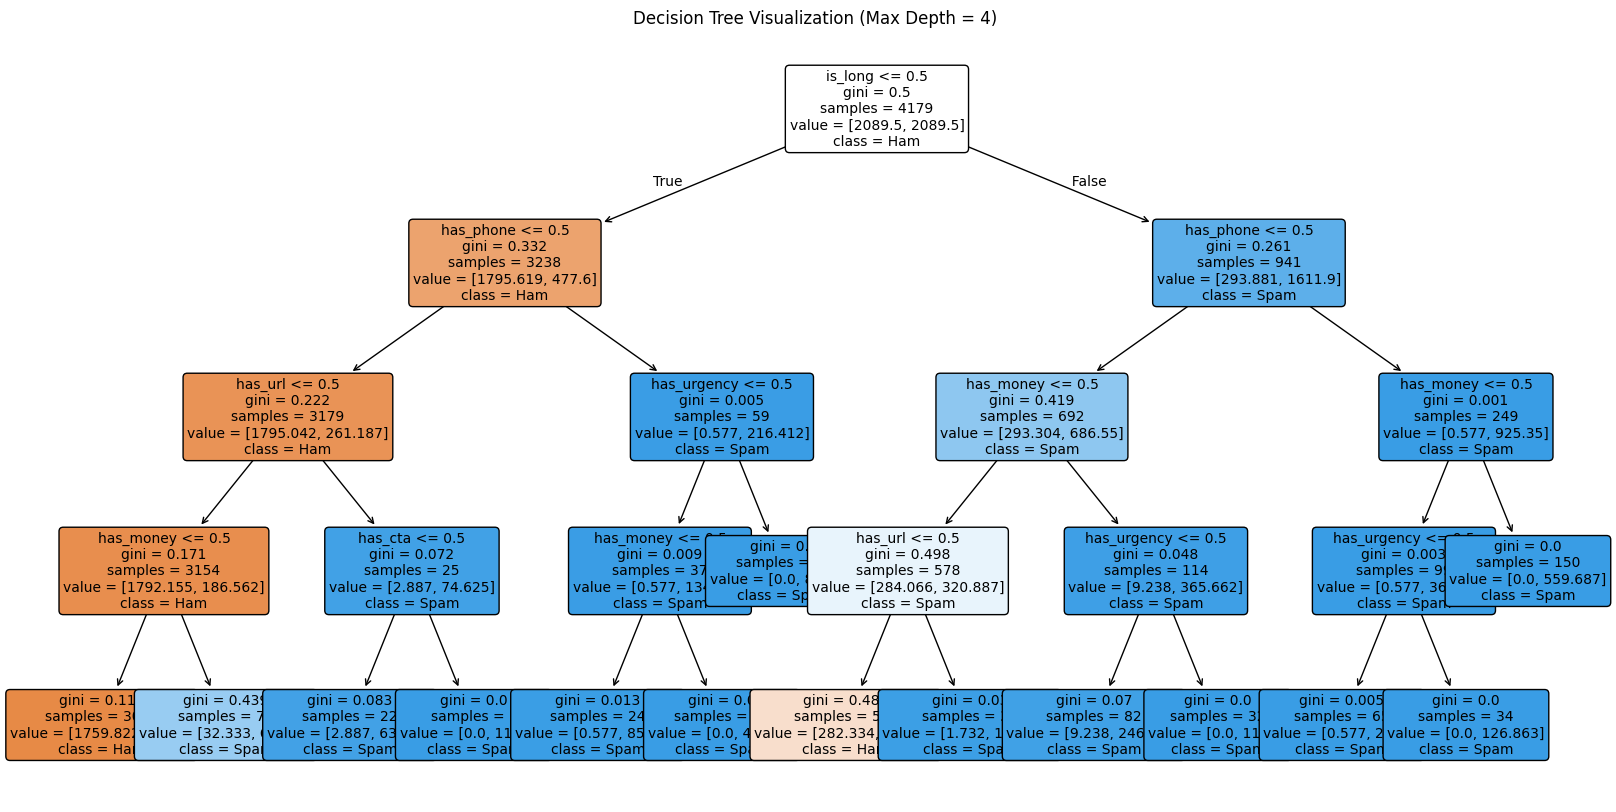

Decision Tree Rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_url <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_url >  0.50
|   |   |   |--- has_cta <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_cta >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 

In [11]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

print(f"Number of leaves in the tree: {dt_model.get_n_leaves()}")
print("-" * 30)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization (Max Depth = 4)")
plt.show()

print("Decision Tree Rules:")
tree_rules = export_text(dt_model, feature_names=feature_cols)
print(tree_rules)

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


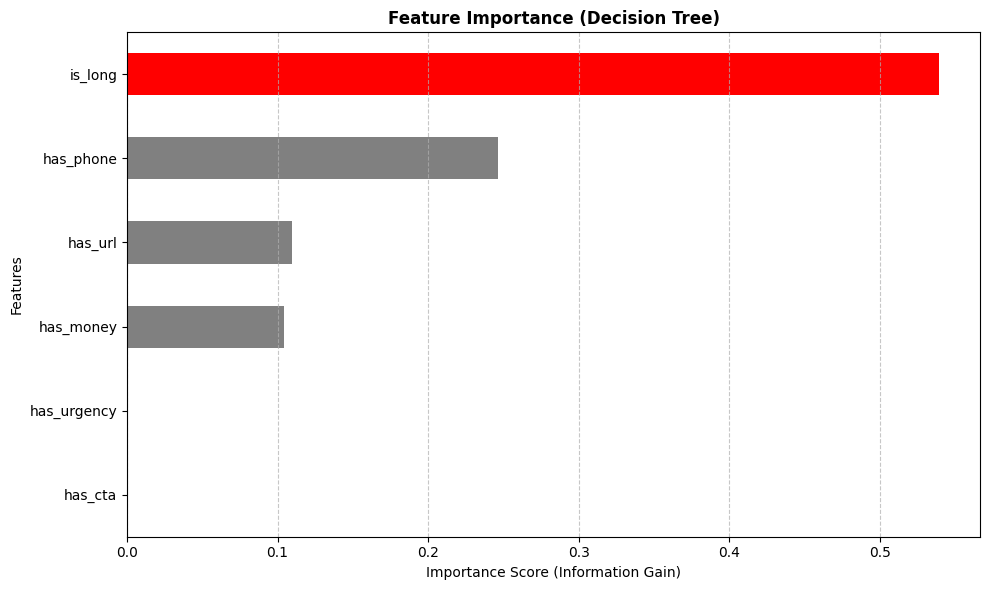

The feature used as the root node is: is_long


In [16]:
importances = dt_model.feature_importances_

feat_importances = pd.Series(importances, index=feature_cols)

feat_importances = feat_importances.sort_values()

colors = ['gray'] * (len(feat_importances) - 1) + ['red']

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color=colors)

plt.title('Feature Importance (Decision Tree)', fontweight='bold')
plt.xlabel('Importance Score (Information Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

root_feature = feat_importances.idxmax()
print(f"The feature used as the root node is: {root_feature}")


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


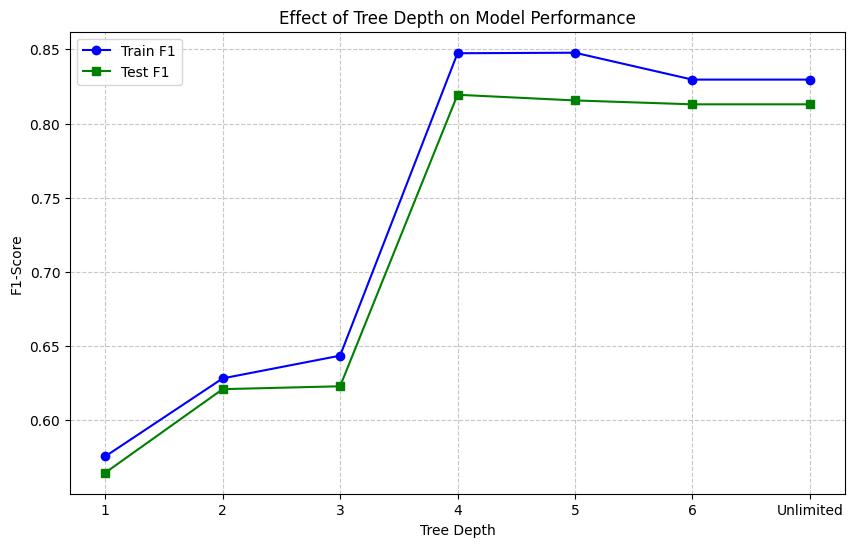

In [20]:
depths = [1, 2, 3, 4, 5, 6, None]

train_f1_scores = []
test_f1_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1_scores.append(f1_score(y_train, y_train_pred))
    test_f1_scores.append(f1_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plot_depths = [str(d) if d is not None else "Unlimited" for d in depths]

plt.plot(plot_depths, train_f1_scores, marker='o', label='Train F1', color='blue')
plt.plot(plot_depths, test_f1_scores, marker='s', label='Test F1', color='green')

plt.xlabel('Tree Depth')
plt.ylabel('F1-Score')
plt.title('Effect of Tree Depth on Model Performance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [22]:
nb_model = BernoulliNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes training complete!")

Naive Bayes training complete!


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


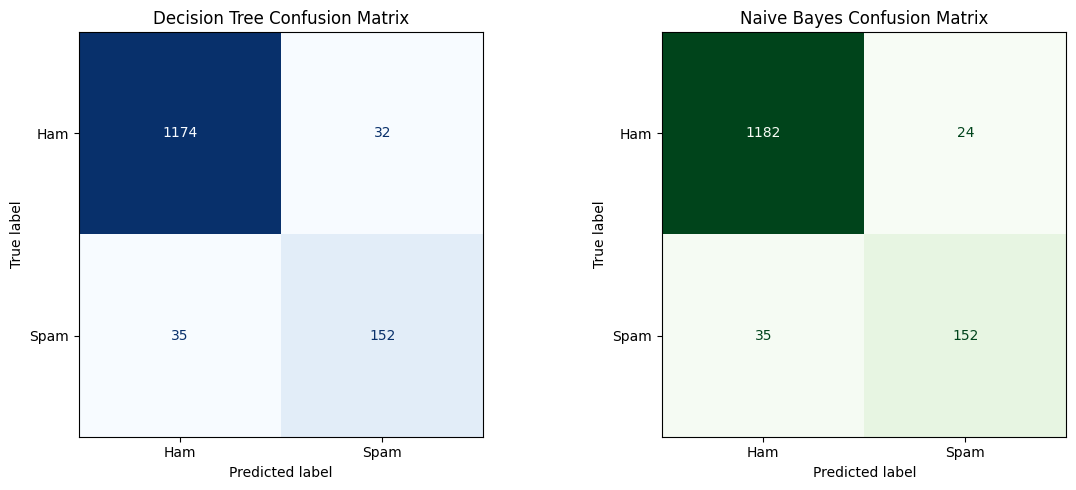

Decision Tree Results:
  True Positives (TP): 152
  False Positives (FP): 32
  False Negatives (FN): 35
  True Negatives (TN): 1174
------------------------------
Naive Bayes Results:
  True Positives (TP): 152
  False Positives (FP): 24
  False Negatives (FN): 35
  True Negatives (TN): 1182


In [24]:
y_pred_dt = dt_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Ham', 'Spam'])
disp_dt.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree Confusion Matrix')

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Ham', 'Spam'])
disp_nb.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()

tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print("Decision Tree Results:")
print(f"  True Positives (TP): {tp_dt}")
print(f"  False Positives (FP): {fp_dt}")
print(f"  False Negatives (FN): {fn_dt}")
print(f"  True Negatives (TN): {tn_dt}")
print("-" * 30)
print("Naive Bayes Results:")
print(f"  True Positives (TP): {tp_nb}")
print(f"  False Positives (FP): {fp_nb}")
print(f"  False Negatives (FN): {fn_nb}")
print(f"  True Negatives (TN): {tn_nb}")

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.951902,0.826087,0.812834,0.819407
1,Naive Bayes,0.957645,0.863636,0.812834,0.837466


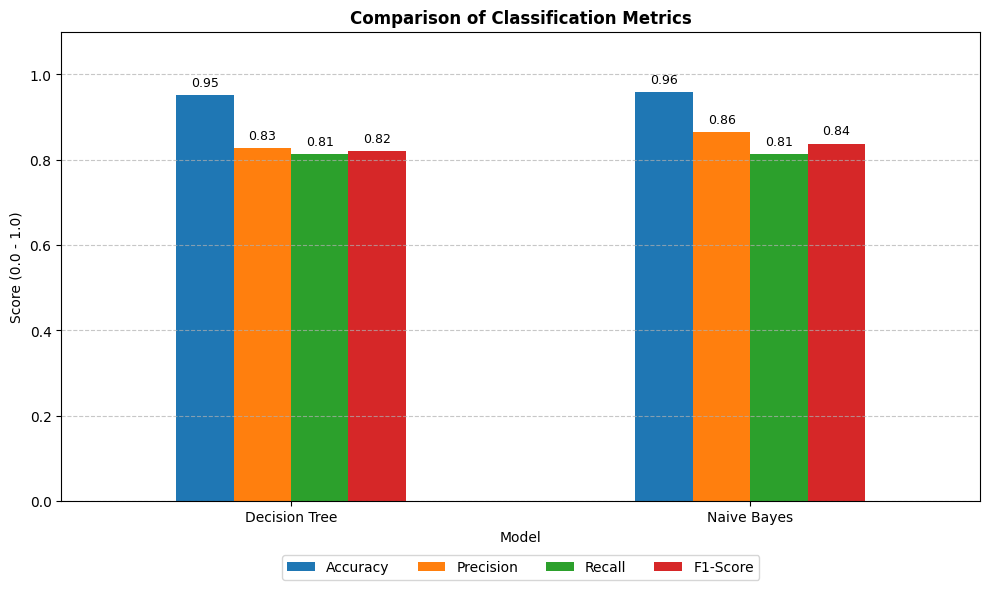

In [25]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_list = [
    get_metrics(y_test, y_pred_dt, 'Decision Tree'),
    get_metrics(y_test, y_pred_nb, 'Naive Bayes')
]
df_metrics = pd.DataFrame(metrics_list)

print("Model Performance Comparison:")
display(df_metrics)

df_plot = df_metrics.set_index('Model')

ax = df_plot.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Comparison of Classification Metrics', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
plt.tight_layout()


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [26]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_scores = cross_val_score(dt_model, X, y, cv=skf, scoring='f1')

nb_cv_scores = cross_val_score(nb_model, X, y, cv=skf, scoring='f1')

print("Average F1-Score (5-Fold Cross-Validation):")
print(f"  Decision Tree: {dt_cv_scores.mean():.4f}")
print(f"  Naive Bayes:   {nb_cv_scores.mean():.4f}")

Average F1-Score (5-Fold Cross-Validation):
  Decision Tree: 0.8405
  Naive Bayes:   0.8579


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> True Positive: 152
False Negatives: 35
False Positives: 32

*Naive Bayes:*
> True Positives: 152
False Negatives: 35
False Positives: 24

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> In Step 1, I chose Precision as the primary metric to minimize the high cost of blocking legitimate "ham" messages. Naive Bayes wins on this metric. While both models caught the same amount of spam (152 TP), Naive Bayes only blocked 24 legitimate messages compared to the Decision Tree's 32. This lower False Positive count results in higher Precision for Naive Bayes.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend implementing the Naive Bayes model for our SMS spam filter. While both models are equally effective at catching spam, Naive Bayes is superior at protecting legitimate user communication, wrongly blocking only 24 messages compared to 32 by the Decision Tree. A potential weakness of this model is the "naive" assumption that all features are independent, which may not always hold true in complex human language. To improve the system further, I propose moving beyond manual binary features and implementing TF-IDF vectorization to allow the model to learn from a much broader vocabulary.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> has_money / has_urgency: Modern spam often mimics professional service notifications (e.g., "Your package delivery failed") rather than using obvious "trigger" words like "WINNER" or "CASH". These more subtle phishing attempts would likely fail to trigger these features.

has_url: While early spam used obvious links, modern spam frequently uses legitimate-looking shortened URLs or redirects that can bypass simple keyword-based detection. If a modern spam message uses a masked or unusual top-level domain that our regex does not account for, it would bypass this filter entirely.